# PRISM-GAN — Notebook 03: Patch extraction, filtering and item-grouped splits (128², native resolution)

**Inputs (verified):** `raw/*.zip` (Notebook 01) and `eda_outputs/garments.csv` (Notebook 02).
**Output on Drive:** `.../DeepFashion-MultiModal/patches_128/` →
`patches_128.zip` (all windows, `manifest.csv`, `clip_embeddings.npy`), plus `manifest.csv`, `patch_summary.json`, `audit_labels.csv`, preview PNGs and `patch_checksums.json`. Section B re-verifies in a fresh runtime.

Decisions carried over from the EDA:
- **128² native crops** (only 57 items have a native 256-px patch; no upsampling)
- classes **floral, striped, lattice, graphic**; *pure color*, *color block* (flat within a patch) and *other* (plain textures) are excluded
- **graphic is filtered to all-over repeat prints** (placed text/logo prints cannot tile — conflicts with Novelty 1)
- splits **grouped by item_id** (≈5.5 views per garment) and stratified by class

**Runtime:** GPU (for CLIP). Same storage pattern as before: extract to local disk, write locally, copy to Drive with size check, flush.

# Section A

## A0. Configuration

In [1]:
import os
BASE = "/content/drive/MyDrive/hari/PRISM-GAN/datasets/DeepFashion-MultiModal"
RAW, EDA = f"{BASE}/raw", f"{BASE}/eda_outputs"
DRIVE_OUT = f"{BASE}/patches_128"
LOCAL = "/content/dfmm_local"               # extracted dataset (shared with Notebook 02)
WORK = "/content/patches_128_local"         # this notebook's outputs, local first

RES = 128
KEEP_CLASSES = ["floral", "striped", "lattice", "graphic"]
K_PER_GARMENT = 4        # max windows per garment
MIN_SEP = 64             # min Chebyshev distance between window centres
MARGIN = 6               # must equal the EDA value (checked below)
SLOT_CLASSES = {"upper": [1, 4, 21], "lower": [3, 5, 6], "outer": [2]}
AUDIT_N = 200
SEED = 42
os.makedirs(f"{WORK}/all", exist_ok=True); os.makedirs(LOCAL, exist_ok=True)

## A1. Mount Drive, verify inputs, extract locally

In [4]:
import json, hashlib, zipfile, shutil, glob, re, collections, random, zlib
import numpy as np, pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
random.seed(SEED); np.random.seed(SEED)

def sha256(path, chunk=16 * 1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""): h.update(b)
    return h.hexdigest()

raw_ref = json.load(open(f"{RAW}/checksums.json"))
for n in ["image.zip", "parsing.zip", "labels.zip", "captions.json"]:
    assert os.path.getsize(f"{RAW}/{n}") == raw_ref[n]["bytes"], f"{n}: size differs from checksums.json"
eda_ref = json.load(open(f"{EDA}/eda_checksums.json"))
assert sha256(f"{EDA}/garments.csv") == eda_ref["garments.csv"]["sha256"], "garments.csv checksum mismatch"
eda_cfg = json.load(open(f"{EDA}/eda_summary.json"))["config"]
assert eda_cfg["MARGIN"] == MARGIN, f"MARGIN {MARGIN} != EDA {eda_cfg['MARGIN']}"
print("inputs verified")

for n in ["image.zip", "parsing.zip"]:
    flag = f"{LOCAL}/{n}.done"
    if os.path.exists(flag): print("[skip]", n); continue
    print("[extract]", n)
    with zipfile.ZipFile(f"{RAW}/{n}") as z: z.extractall(LOCAL)
    open(flag, "w").close()
shutil.copyfile(f"{EDA}/garments.csv", f"{WORK}/garments_input.csv")

def stem(n): return re.sub(r"(_segm)?\.(jpg|png|jpeg)$", "", os.path.basename(n), flags=re.I)
img_path = {stem(p): p for p in glob.glob(f"{LOCAL}/images/*.jpg")}
mask_path = {stem(p): p for p in glob.glob(f"{LOCAL}/segm/*.png")}
assert len(img_path) == 44096 and len(mask_path) == 12701, (len(img_path), len(mask_path))
caps = {stem(k): v for k, v in json.load(open(f"{RAW}/captions.json")).items()}

g = pd.read_csv(f"{WORK}/garments_input.csv", dtype={"item_id": str})
cand = g[g.pattern.isin(KEEP_CLASSES) & (g.square_side >= RES)].reset_index(drop=True)
print("candidate garments (side >= 128):"); print(cand.pattern.value_counts().to_string())

Mounted at /content/drive
inputs verified
[extract] image.zip
[extract] parsing.zip
candidate garments (side >= 128):
pattern
graphic    2615
striped     508
floral      411
lattice     191


## A2. Window extraction

A 128-px window centred at (y, x) lies fully inside the eroded garment mask iff the chessboard distance transform there is ≥ 65.
Windows are sampled greedily (largest-square centre first, then seeded random) with centres ≥ `MIN_SEP` apart, up to `K_PER_GARMENT` per garment. Crops are native resolution; nothing is resized.

In [5]:
from scipy import ndimage
from concurrent.futures import ThreadPoolExecutor
NEED = RES // 2 + 1

def extract(rec):
    rng = np.random.default_rng(zlib.crc32(f"{rec.stem}|{rec.slot}|{SEED}".encode()))
    mask = np.array(Image.open(mask_path[rec.stem]))
    if mask.ndim == 3: mask = mask[..., 0]
    region = np.isin(mask, SLOT_CLASSES[rec.slot])
    if MARGIN: region = ndimage.binary_erosion(region, iterations=MARGIN)
    dt = ndimage.distance_transform_cdt(region, metric="chessboard")
    ys, xs = np.nonzero(dt >= NEED)
    if len(ys) == 0: return []
    order = np.concatenate([[np.argmax(dt[ys, xs])], rng.permutation(len(ys))])
    centres = []
    for i in order:
        y, x = int(ys[i]), int(xs[i])
        if all(max(abs(y - a), abs(x - b)) >= MIN_SEP for a, b in centres):
            centres.append((y, x))
            if len(centres) == K_PER_GARMENT: break
    im = Image.open(img_path[rec.stem]).convert("RGB")
    out = []
    for k, (y, x) in enumerate(centres):
        crop = im.crop((x - RES // 2, y - RES // 2, x + RES // 2, y + RES // 2))
        assert crop.size == (RES, RES)
        name = f"{rec.stem}__{rec.slot}__{k}.png"
        crop.save(f"{WORK}/all/{name}")
        out.append(dict(file=name, stem=rec.stem, item_id=rec.item_id, slot=rec.slot,
                        pattern=rec.pattern, fabric=rec.fabric, cy=y, cx=x))
    return out

with ThreadPoolExecutor(max_workers=8) as ex:
    rows = [r for rs in tqdm(ex.map(extract, cand.itertuples()), total=len(cand)) for r in rs]
W = pd.DataFrame(rows)
print(len(W), "windows from", W.groupby(["stem", "slot"]).ngroups, "garments /", W.item_id.nunique(), "items")
print(W.pattern.value_counts().to_string())

  0%|          | 0/3725 [00:00<?, ?it/s]

8122 windows from 3725 garments / 2600 items
pattern
graphic    5644
striped    1214
floral      867
lattice     397


## A3. Scores
- **energy** — std of high-passed luminance (Gaussian σ=8 removed); low = flat / blurred / plain
- **periodicity** — max off-centre peak of the window-corrected autocorrelation of the high-passed luminance (0–1); repeats score high
- **p_repeat** — CLIP zero-shot probability of "all-over repeating fabric pattern" vs "placed print / text / logo"

In [6]:
from scipy.ndimage import gaussian_filter
HANN = np.outer(np.hanning(RES), np.hanning(RES))
def _ac(x):
    F = np.fft.fft2(x); return np.fft.fftshift(np.fft.ifft2(np.abs(F) ** 2).real)
AC_W = _ac(HANN); AC_W /= AC_W.max()
yy, xx = np.mgrid[:RES, :RES] - RES // 2
VALID = (np.hypot(yy, xx) > 6) & (np.abs(yy) <= RES // 3) & (np.abs(xx) <= RES // 3) & (AC_W > 0.1)

def texture_scores(fname):
    a = np.asarray(Image.open(f"{WORK}/all/{fname}").convert("L"), dtype=np.float32)
    hp = a - gaussian_filter(a, 8)
    ac = _ac((hp - hp.mean()) * HANN)
    if ac.max() <= 0: return float(hp.std()), 0.0
    ac = ac / ac.max() / np.maximum(AC_W, 1e-6)
    return float(hp.std()), float(np.clip(ac[VALID].max(), 0, 1))

with ThreadPoolExecutor(max_workers=8) as ex:
    sc = list(tqdm(ex.map(texture_scores, W.file), total=len(W)))
W["energy"], W["periodicity"] = zip(*sc)
print(W.groupby("pattern")[["energy", "periodicity"]].median().round(3))

  0%|          | 0/8122 [00:00<?, ?it/s]

         energy  periodicity
pattern                     
floral   49.306        0.189
graphic  35.651        0.337
lattice  39.607        0.595
striped  53.822        0.900


In [7]:
import torch
from transformers import CLIPModel, CLIPProcessor
DEV = "cuda" if torch.cuda.is_available() else "cpu"
assert DEV == "cuda", "switch to a GPU runtime (Runtime -> Change runtime type)"
CLIP_NAME = "openai/clip-vit-large-patch14"
clip = CLIPModel.from_pretrained(CLIP_NAME).to(DEV).eval()
proc = CLIPProcessor.from_pretrained(CLIP_NAME)

def _t(o):  # transformers versions differ in what get_*_features returns
    if torch.is_tensor(o): return o
    for k in ("image_embeds", "text_embeds", "pooler_output"):
        v = getattr(o, k, None)
        if v is not None: return v
    return o[0]

REPEAT = ["a close-up photo of fabric with an all-over repeating pattern", "a seamless textile print",
          "a close-up of floral fabric", "a close-up of striped fabric", "a close-up of plaid fabric",
          "an all-over geometric print on fabric"]
PLACED = ["a t-shirt with printed text", "a logo printed on a shirt", "a slogan t-shirt",
          "a single large graphic printed on the front of a shirt", "a cartoon character printed on clothing"]
with torch.no_grad():
    t = proc(text=REPEAT + PLACED, return_tensors="pt", padding=True).to(DEV)
    T = torch.nn.functional.normalize(_t(clip.get_text_features(**t)).float(), dim=-1).cpu()

E = []
for i in tqdm(range(0, len(W), 128)):
    ims = [Image.open(f"{WORK}/all/{f}").convert("RGB") for f in W.file.iloc[i:i + 128]]
    with torch.no_grad():
        px = proc(images=ims, return_tensors="pt")["pixel_values"].to(DEV)
        E.append(torch.nn.functional.normalize(_t(clip.get_image_features(pixel_values=px)).float(), dim=-1).cpu())
E = torch.cat(E)
logits = clip.logit_scale.exp().item() * (E @ T.T)
W["p_repeat"] = torch.sigmoid(torch.logsumexp(logits[:, :len(REPEAT)], 1) - torch.logsumexp(logits[:, len(REPEAT):], 1)).numpy()
np.save(f"{WORK}/clip_embeddings.npy", E.numpy())
print(W.groupby("pattern")["p_repeat"].describe()[["25%", "50%", "75%"]].round(3))

config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.71GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

  0%|          | 0/64 [00:00<?, ?it/s]

           25%    50%    75%
pattern                     
floral   0.991  0.997  0.999
graphic  0.817  0.977  0.994
lattice  0.959  0.985  0.997
striped  0.953  0.983  0.994


## A4. Manual audit of the graphic filter

The next cell shows 200 randomly sampled **graphic** windows, numbered #0–#199.
In the cell after it, list the numbers of every crop that is **NOT an all-over repeat print** — placed text, logos, a single large graphic, or a plain/solid area. Everything you do not list counts as a repeat print.
These labels choose the filter rule and give the precision/recall to report in the paper.

In [8]:
gw = W[W.pattern == "graphic"]
audit = gw.sample(min(AUDIT_N, len(gw)), random_state=SEED).reset_index().rename(columns={"index": "w_index"})
audit.insert(0, "idx", range(len(audit)))
PER_PAGE, COLS = 40, 8
for p in range(0, len(audit), PER_PAGE):
    page = audit.iloc[p:p + PER_PAGE]; rows_ = int(np.ceil(len(page) / COLS))
    fig, axes = plt.subplots(rows_, COLS, figsize=(COLS * 1.8, rows_ * 2.0), squeeze=False)
    for ax in axes.flat: ax.axis("off")
    for ax, r in zip(axes.flat, page.itertuples()):
        ax.imshow(Image.open(f"{WORK}/all/{r.file}")); ax.set_title(f"#{r.idx}", fontsize=10)
    plt.tight_layout(); plt.savefig(f"{WORK}/audit_sheet_{p // PER_PAGE}.png", dpi=110); plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [11]:
NOT_REPEAT = [1, 3, 7, 10, 11, 12, 18, 19, 20, 22, 23, 25, 29, 30, 31, 37,
              40, 50, 62, 63, 65, 67, 70, 76, 78,
              81, 84, 87, 88, 90, 91, 96, 97, 102, 105, 106, 107, 108, 115, 116, 119,
              120, 122, 128, 131, 133, 134, 135, 136, 137, 140, 142, 143, 144, 145, 148, 152, 154, 156, 157,
              162, 165, 167, 170, 172, 175, 176, 184, 185, 190, 191, 193, 195, 196, 199]

ref_energy = W[W.pattern.isin(["floral", "striped", "lattice"])].energy
E_MIN = float(np.percentile(ref_energy, 3))
RULE, AUDITED = dict(kind="clip", tau_clip=0.5, tau_per=None, e_min=E_MIN), False

if NOT_REPEAT is not None:
    bad = set(NOT_REPEAT); assert bad <= set(audit.idx), "numbers outside 0..199"
    audit["repeat"] = (~audit.idx.isin(bad)).astype(int)
    audit[["idx", "file", "p_repeat", "periodicity", "energy", "repeat"]].to_csv(f"{WORK}/audit_labels.csv", index=False)
    AUDITED, y = True, audit.repeat.values

    print("Median scores by your label (1 = repeat, 0 = not repeat):")
    print(audit.groupby("repeat")[["p_repeat", "periodicity", "energy"]].median().round(3), "\n")

    e_grid = sorted({E_MIN} | {float(np.percentile(ref_energy, q)) for q in (5, 10, 15, 20, 25, 30)})
    res = []
    for em in e_grid:
        e_ok = audit.energy.values >= em
        for tc in np.arange(0.20, 0.96, 0.05):
            for tp in np.arange(0.10, 0.91, 0.05):
                a, b = audit.p_repeat.values >= tc, audit.periodicity.values >= tp
                for kind, pr in [("clip", a), ("per", b), ("and", a & b), ("or", a | b)]:
                    pred = (pr & e_ok).astype(int); tp_ = int((pred & y).sum())
                    prec, rec = tp_ / max(pred.sum(), 1), tp_ / max(y.sum(), 1)
                    res.append((2 * prec * rec / max(prec + rec, 1e-9), prec, rec, kind,
                                round(float(tc), 2), round(float(tp), 2), round(em, 3)))
    res = pd.DataFrame(res, columns=["f1", "prec", "rec", "kind", "tau_clip", "tau_per", "e_min"])
    ok = res[res.prec >= 0.90]
    if len(ok) == 0:
        print("Best achievable precision:", round(res.prec.max(), 3))
        print(res.sort_values(["prec", "rec"], ascending=False).head(10).round(3))
        raise AssertionError("still no rule with precision >= 0.90 — paste this output to Claude")
    b = ok.sort_values(["f1", "prec"], ascending=False).iloc[0]
    RULE = dict(kind=b.kind,
                tau_clip=float(b.tau_clip) if b.kind != "per" else None,
                tau_per=float(b.tau_per) if b.kind != "clip" else None,
                e_min=float(b.e_min),
                audit_precision=round(float(b.prec), 3), audit_recall=round(float(b.rec), 3),
                audit_f1=round(float(b.f1), 3), audit_n=int(len(audit)),
                audit_repeat_rate=round(float(y.mean()), 3))
print("AUDITED:", AUDITED, "| RULE:", RULE)

Median scores by your label (1 = repeat, 0 = not repeat):
        p_repeat  periodicity  energy
repeat                               
0          0.823        0.457  17.480
1          0.991        0.238  45.147 

AUDITED: True | RULE: {'kind': 'clip', 'tau_clip': 0.9, 'tau_per': None, 'e_min': 29.026, 'audit_precision': 0.9, 'audit_recall': 0.648, 'audit_f1': 0.753, 'audit_n': 200, 'audit_repeat_rate': 0.625}


## A5. Keep / drop
- all classes: drop windows with energy below the 3rd percentile of floral/striped/lattice windows (flat, blurred, plain)
- graphic: keep only windows passing the rule; drop a graphic garment entirely if fewer than half its windows pass

E_MIN = 6.22
reason   KEPT  flat  garment_mostly_placed  placed_print
pattern                                                 
floral    857    10                      0             0
graphic  2331   686                     56          2571
lattice   382    15                      0             0
striped  1164    50                      0             0


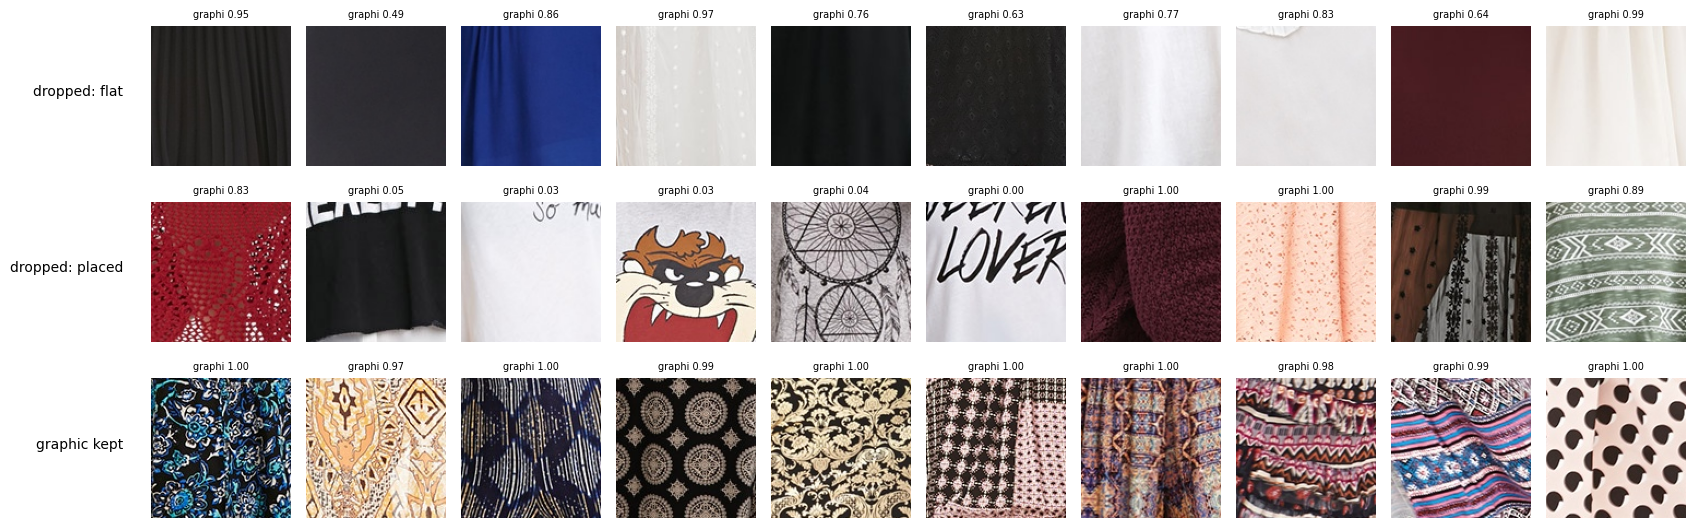

In [12]:
E_MIN = float(np.percentile(W[W.pattern.isin(["floral", "striped", "lattice"])].energy, 3))
def passes(r):
    c, p, k = RULE.get("tau_clip"), RULE.get("tau_per"), RULE["kind"]
    a = r.p_repeat >= c if c is not None else True
    b = r.periodicity >= p if p is not None else True
    ok = (a or b) if k == "or" else (a and b)
    return ok and r.energy >= RULE.get("e_min", E_MIN)

W["reason"] = np.where(W.energy < E_MIN, "flat", "")
gm = (W.pattern == "graphic") & (W.reason == "")
W.loc[gm, "reason"] = np.where(W[gm].apply(passes, axis=1), "", "placed_print")
gw_ok = W[W.pattern == "graphic"].assign(ok=lambda d: d.reason == "").groupby(["stem", "slot"]).ok.mean()
bad_g = set(gw_ok[gw_ok < 0.5].index)
sel = (W.pattern == "graphic") & (W.reason == "") & pd.Series(list(zip(W.stem, W.slot))).isin(bad_g).values
W.loc[sel, "reason"] = "garment_mostly_placed"
W["keep"] = W.reason == ""
print("E_MIN =", round(E_MIN, 3)); print(pd.crosstab(W.pattern, W.reason.replace("", "KEPT")))

fig, axes = plt.subplots(3, 10, figsize=(17, 5.5))
for row, (lab, sub) in enumerate([("dropped: flat", W[W.reason == "flat"]),
                                  ("dropped: placed", W[W.reason == "placed_print"]),
                                  ("graphic kept", W[W.keep & (W.pattern == "graphic")])]):
    pick = sub.sample(min(10, len(sub)), random_state=SEED)
    for j, ax in enumerate(axes[row]):
        ax.axis("off")
        if j < len(pick):
            r = pick.iloc[j]; ax.imshow(Image.open(f"{WORK}/all/{r.file}")); ax.set_title(f"{r.pattern[:6]} {r.p_repeat:.2f}", fontsize=7)
    axes[row, 0].text(-0.2, .5, lab, transform=axes[row, 0].transAxes, ha="right")
plt.tight_layout(); plt.savefig(f"{WORK}/filter_examples.png", dpi=130); plt.show()

## A6. Item-grouped, class-stratified splits (80/10/10) + cross-split near-duplicate check

In [13]:
from sklearn.model_selection import StratifiedGroupKFold
K = W[W.keep].copy()
maj = K.groupby("item_id").pattern.agg(lambda s: s.value_counts().index[0])
items = maj.index.values
folds = [te for _, te in StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=SEED).split(items, maj.values, groups=items)]
split_of = {it: "train" for it in items}
for it in items[folds[0]]: split_of[it] = "test"
for it in items[folds[1]]: split_of[it] = "val"
K["split"] = K.item_id.map(split_of)

# the same print sold under different item_ids would leak: move such val/test items into train
DUP_TAU = 0.95
Ek = torch.from_numpy(np.load(f"{WORK}/clip_embeddings.npy"))[K.index.values]
tr = torch.from_numpy((K.split == "train").values)
sims = (Ek[~tr] @ Ek[tr].T).max(1).values.numpy()
held = K[~tr.numpy()].assign(max_sim_to_train=sims)
dup_items = set(held[held.max_sim_to_train >= DUP_TAU].item_id)
K.loc[K.item_id.isin(dup_items), "split"] = "train"
assert K.groupby("item_id").split.nunique().max() == 1, "item leakage across splits"
print(f"near-duplicate items moved to train: {len(dup_items)}")
print(pd.crosstab(K.pattern, K.split, margins=True)); print(K.groupby("split").item_id.nunique())

near-duplicate items moved to train: 125
split    test  train  val   All
pattern                        
floral     37    790   30   857
graphic   164   2002  165  2331
lattice     9    363   10   382
striped    30   1111   23  1164
All       240   4266  228  4734
split
test       87
train    1291
val        80
Name: item_id, dtype: int64


## A7. Conditioning metadata (Novelty 2): 5-colour Lab palette, prompt, caption

In [14]:
from skimage.color import rgb2lab
from sklearn.cluster import KMeans
def palette(fname, k=5):
    lab = rgb2lab(np.asarray(Image.open(f"{WORK}/all/{fname}").convert("RGB").resize((64, 64)), dtype=np.float32) / 255.).reshape(-1, 3)
    km = KMeans(k, n_init=3, random_state=SEED).fit(lab)
    w = np.bincount(km.labels_, minlength=k) / len(lab); o = np.argsort(-w)
    return json.dumps({"lab": km.cluster_centers_[o].round(2).tolist(), "w": w[o].round(4).tolist()})
K["palette"] = [palette(f) for f in tqdm(K.file)]
FAB_OK = {"denim", "cotton", "leather", "furry", "knitted", "chiffon"}
K["prompt"] = [f"{p} {f} fabric pattern" if f in FAB_OK else f"{p} fabric pattern" for p, f in zip(K.pattern, K.fabric)]
K["caption"] = K.stem.map(caps).fillna("")
CLASSES = sorted(KEEP_CLASSES); K["class_idx"] = K.pattern.map({c: i for i, c in enumerate(CLASSES)})

  0%|          | 0/4734 [00:00<?, ?it/s]

## A8. Manifest, summary, previews

{
  "resolution": 128,
  "classes": [
    "floral",
    "graphic",
    "lattice",
    "striped"
  ],
  "windows_extracted": 8122,
  "windows_kept": 4734,
  "drop_reasons": {
    "KEPT": 4734,
    "placed_print": 2571,
    "flat": 761,
    "garment_mostly_placed": 56
  },
  "graphic_rule": {
    "kind": "clip",
    "tau_clip": 0.9,
    "tau_per": null,
    "e_min": 29.026,
    "audit_precision": 0.9,
    "audit_recall": 0.648,
    "audit_f1": 0.753,
    "audit_n": 200,
    "audit_repeat_rate": 0.625
  },
  "audited": true,
  "energy_min": 6.2205,
  "per_split_windows": {
    "train": 4266,
    "test": 240,
    "val": 228
  },
  "per_split_items": {
    "test": 87,
    "train": 1291,
    "val": 80
  },
  "per_class_split_windows": {
    "floral": {
      "train": 790,
      "test": 37,
      "val": 30
    },
    "graphic": {
      "train": 2002,
      "val": 165,
      "test": 164
    },
    "lattice": {
      "train": 363,
      "val": 10,
      "test": 9
    },
    "striped": {
      "

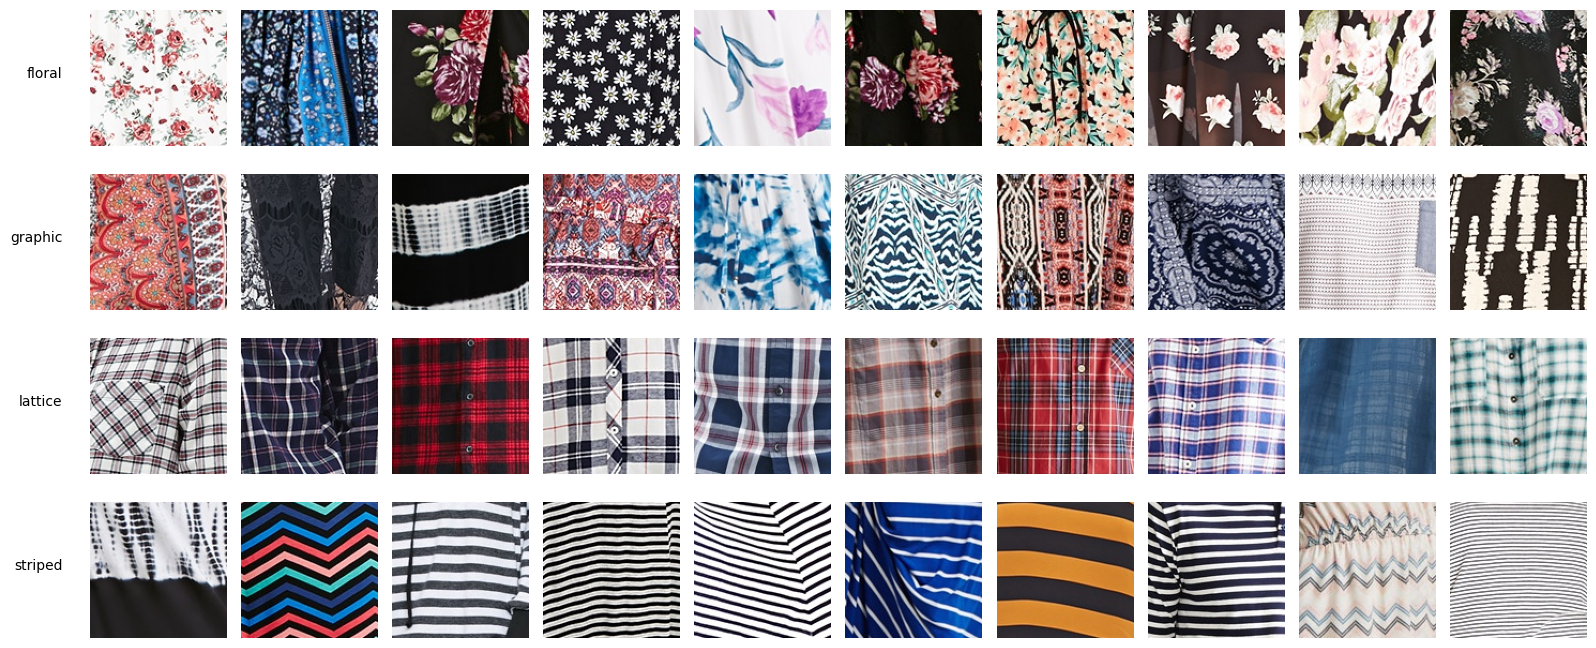

In [15]:
man = W.merge(K[["file", "split", "palette", "prompt", "caption", "class_idx"]], on="file", how="left")
man.to_csv(f"{WORK}/manifest.csv", index=False)
summary = {
    "resolution": RES, "classes": CLASSES, "windows_extracted": int(len(W)), "windows_kept": int(len(K)),
    "drop_reasons": {k: int(v) for k, v in W.reason.replace("", "KEPT").value_counts().items()},
    "graphic_rule": RULE, "audited": AUDITED, "energy_min": round(E_MIN, 4),
    "per_split_windows": {k: int(v) for k, v in K.split.value_counts().items()},
    "per_split_items": {k: int(v) for k, v in K.groupby("split").item_id.nunique().items()},
    "per_class_split_windows": {c: {s: int(v) for s, v in K[K.pattern == c].split.value_counts().items()} for c in CLASSES},
    "near_duplicate_items_moved_to_train": len(dup_items),
    "config": dict(K_PER_GARMENT=K_PER_GARMENT, MIN_SEP=MIN_SEP, MARGIN=MARGIN, DUP_TAU=DUP_TAU, SEED=SEED, CLIP=CLIP_NAME),
}
json.dump(summary, open(f"{WORK}/patch_summary.json", "w"), indent=2); print(json.dumps(summary, indent=2))

fig, axes = plt.subplots(len(CLASSES), 10, figsize=(16, len(CLASSES) * 1.7), squeeze=False)
for i, c in enumerate(CLASSES):
    sub = K[(K.pattern == c) & (K.split == "train")]
    for ax, r in zip(axes[i], sub.sample(min(10, len(sub)), random_state=SEED).itertuples()):
        ax.imshow(Image.open(f"{WORK}/all/{r.file}")); ax.axis("off")
    for ax in axes[i]: ax.axis("off")
    axes[i, 0].text(-0.2, .5, c, transform=axes[i, 0].transAxes, ha="right")
plt.tight_layout(); plt.savefig(f"{WORK}/final_train_samples.png", dpi=130); plt.show()

## A9. Store on Drive (zip + key files; temp name → size check → rename) and flush

In [16]:
arch = shutil.make_archive("/content/patches_128", "zip", WORK, ".")   # all/ + manifest + embeddings + summary
with zipfile.ZipFile(arch) as z:
    assert z.testzip() is None, "local zip failed CRC check"
    n_png = sum(m.replace("./", "", 1).startswith("all/") and m.endswith(".png") for m in z.namelist())
assert n_png == len(W), f"zip holds {n_png} windows, expected {len(W)}"

drive.mount("/content/drive", force_remount=True)
os.makedirs(DRIVE_OUT, exist_ok=True)
probe = f"{DRIVE_OUT}/.write_probe"
with open(probe, "w") as f: f.write("ok")
assert open(probe).read() == "ok"; os.remove(probe)

to_store = {"patches_128.zip": arch}
for f in ["manifest.csv", "patch_summary.json", "audit_labels.csv", "filter_examples.png", "final_train_samples.png"]:
    if os.path.exists(f"{WORK}/{f}"): to_store[f] = f"{WORK}/{f}"
checks = {}
for name, src in to_store.items():
    dst = f"{DRIVE_OUT}/{name}"; tmp = dst + ".partial"
    shutil.copyfile(src, tmp)
    assert os.path.getsize(tmp) == os.path.getsize(src), f"size mismatch: {name}"
    os.replace(tmp, dst)
    checks[name] = {"bytes": os.path.getsize(src), "sha256": sha256(src)}
    print(f"[stored] {name:26s} {checks[name]['bytes']:>14,} bytes")
json.dump(checks, open(f"{DRIVE_OUT}/patch_checksums.json", "w"), indent=2)
drive.flush_and_unmount()
print("Drive flushed. Now: Runtime -> Disconnect and delete runtime, then run Section B.")

Mounted at /content/drive
[stored] patches_128.zip               288,173,546 bytes
[stored] manifest.csv                    4,718,077 bytes
[stored] patch_summary.json                  1,265 bytes
[stored] audit_labels.csv                   21,530 bytes
[stored] filter_examples.png             1,611,604 bytes
[stored] final_train_samples.png         2,694,341 bytes
Drive flushed. Now: Runtime -> Disconnect and delete runtime, then run Section B.


# Section B — verify the stored patches (fresh runtime, CPU is fine)

In [1]:
import os, json, hashlib, zipfile
from google.colab import drive
drive.mount("/content/drive")
DRIVE_OUT = "/content/drive/MyDrive/hari/PRISM-GAN/datasets/DeepFashion-MultiModal/patches_128"

def sha256(path, chunk=16 * 1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""): h.update(b)
    return h.hexdigest()

ref = json.load(open(f"{DRIVE_OUT}/patch_checksums.json"))
all_ok = True
for name, info in ref.items():
    p = f"{DRIVE_OUT}/{name}"
    ok = os.path.exists(p) and os.path.getsize(p) == info["bytes"] and sha256(p) == info["sha256"]
    all_ok &= ok; print(f"{'PASS' if ok else 'FAIL'}  {name}")
with zipfile.ZipFile(f"{DRIVE_OUT}/patches_128.zip") as z:
    crc_ok = z.testzip() is None
print(f"{'PASS' if crc_ok else 'FAIL'}  patches_128.zip CRC of every member")
print("\nPATCH DATASET STORED AND VERIFIED" if all_ok and crc_ok else "\nSOME CHECKS FAILED — rerun A9")

Mounted at /content/drive
PASS  patches_128.zip
PASS  manifest.csv
PASS  patch_summary.json
PASS  audit_labels.csv
PASS  filter_examples.png
PASS  final_train_samples.png
PASS  patches_128.zip CRC of every member

PATCH DATASET STORED AND VERIFIED
